### The Liquid Drop Model for Nuclear Binding Energy

Inspired by work by Morten Hjorth-Jensen, Department of Physics, University of Oslo, for the course "Applied Data Analysis and Machine Learning"

A basic quantity which can be measured for the ground states of nuclei is the atomic mass $M(N, Z)$ of the neutral atom with atomic mass number $A$, charge $Z$, and number of neutrons $N$. There are indeed several sophisticated experiments worldwide which allow us to measure this quantity to high precision (parts per million even).

Atomic masses are usually tabulated in terms of the mass excess defined by
$$ \Delta M(N, Z) = M(N, Z) - u A $$
where $u$ is the Atomic Mass Unit:
$$ u = M(^{12}C)/12 = 931.4940954(57) MeV/c^2 $$

The nucleon masses are
$$ m_p = 1.00727646693(9) u $$
and
$$ m_n = 1.0086649156(6) u $$

The nuclear binding energy is defined as the energy required to break up a given nucleus into its constituent parts of $N$ neutrons and $Z$ protons. In terms of the atomic masses $M(N, Z)$ the binding energy is defined by
$$ BE(N,Z) = Z M_H c^2 + N m_n c^2 - M(N, Z) c^2 $$
where $M_H$ is the mass of the hydrogen atom and $m_n$ is the mass of the neutron. 

In terms of the mass excess the binding energy is given by
$$ BE(N,Z) = Z \Delta_H c^2 + N \Delta_n c^2 - \Delta(N, Z) c^2 $$
where $\Delta_H c^2 = 7.2890$ MeV  is the mass excess of the hydrogen atom and $\Delta_n c^2 = 8.0713$ MeV is the mass excess of the neutron.

A popular and physically intuitive model which can be used to parametrize the experimental binding energies as function of $A$ is the so-called liquid drop model. The ansatz is based on the following expression

$$BE(N, Z) = a_1 A - a_2 A^{2/3} - a_3 \frac{Z^2}{A^1/3} - a_4 \frac{(N-Z)^2}{A} $$
 
 
where $A$ is the number of nucleons and the $a_i$ 's are parameters which are determined by a fit to the experimental data.

To arrive at the above expression we have assumed that we can make the following assumptions:

- There is a volume term $a_1 A$ that proportional with the number of nucleons. When an assembly of nucleons of the same size is packed together into the smallest volume, each interior nucleon has a certain number of other nucleons in contact with it. This contribution is proportional to the volume.

- There is a surface energy term $a_2 A^{2/3}$. The assumption here is that a nucleon at the surface of a nucleus interacts with fewer other nucleons than one in the interior of the nucleus and hence its binding energy is less. This surface energy term takes that into account and is therefore negative and is proportional to the surface area.

- There is a Coulomb energy term $a_3 \frac{Z^2}{A^1/3}$, since the electric repulsion between each pair of protons in a nucleus yields less binding.

- There is an asymmetry term $a_4 \frac{(N-Z)^2}{A}$. This term is associated with the Pauli exclusion principle and reflects the fact that the proton-neutron interaction is more attractive on the average than the neutron-neutron and proton-proton interactions.

The liquid drop model does not take into account the shell structure of the nucleus, so it tends to provide a good fit to heavier nuclei, and a poor fit to lighter nuclei. 

### In this homework problem, we will use linear regression to fit the parameters of the liquid drop model and predict nuclear masses. 

### Step 1: Load the data and calculate the targets
A subset of the data from the 2020 Atomic Mass Evaluation (AME2020) has been provided in the atomic_masses.csv file (contained in the Data folder on Github). The publications containing the data can be found here: Chinese Phys. C 45 030002 (2021), and Chinese Phys. C 45 030003 (2021). 

The data file contains N, Z, A, the element, the mass excess (in $keV/c^2$), and the atomic mass (in $u$) for each of 2550 nuclei.

Load the data into a pandas data frame. 

We want to train a model for the binding energies of the nuclei, which isn't provided in the data set. Using the expression(s) above, evaluate the true value of the binding energy for each nucleus in the data set, saving the values to an array or data frame.

In [43]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

data = pd.read_csv('../Data/atomic_masses.csv')
data

,N,Z,El,Mass_Excess,Atomic Mass
0,0,1,H,7288.97106,1.007825
1,1,1,H,13135.72290,2.014101
2,2,1,H,14949.81090,3.016049
3,1,2,He,14931.21888,3.016029
4,3,1,H,24620.00000,4.026430
...,...,...,...,...,...
2544,157,108,Hs,120900.00000,265.129792
2545,158,108,Hs,121140.00000,266.130049
2546,157,109,Mt,127670.00000,266.137060
2547,159,110,Ds,134830.00000,269.144750


### Step 2: Select features and perform feature engineering

Based on the liquid drop model above, select the appropriate features from the provided data and engineer any new features you think will be useful, saving all of the features as columns to a new data frame X. Make sure you don't include anything that shouldn't be a feature. You don't need to include a bias feature (1 for all instances), since sk-learn's methods include fitting the y intercept by default.

In [44]:
data.columns = ['N', 'Z', 'El', 'Excess Mass', 'A']


data['A 2/3'] = data['A'] ** (2/3)
data['Z2 A1/3'] = (data['Z'] ** 2) * (data['A'] ** (1/3))
data['(N-Z)^2 /A'] = ((data['N'] - data['Z']) ** 2) / data['A']

X = data.drop(columns='El')

X

,N,Z,Excess Mass,A,A 2/3,Z2 A1/3,(N-Z)^2 /A
0,0,1,7288.97106,1.007825,1.005210,1.002602,0.992236
1,1,1,13135.72290,2.014101,1.594854,1.262875,0.000000
2,2,1,14949.81090,3.016049,2.087496,1.444817,0.331560
3,1,2,14931.21888,3.016029,2.087486,5.779255,0.331562
4,3,1,24620.00000,4.026430,2.530930,1.590890,0.993436
...,...,...,...,...,...,...,...
2544,157,108,120900.00000,265.129792,41.270433,74931.947703,9.055942
2545,158,108,121140.00000,266.130049,41.374168,75026.061540,9.393904
2546,157,109,127670.00000,266.137060,41.374895,76422.536412,8.657193
2547,159,110,134830.00000,269.144750,41.686037,78123.317013,8.920850


Explain what features you included and your reasoning.

>I removed the electron feature because it didn't appear in the background information given above. I added A 2/3, Z2 A1/3, and (N-Z)^2 /A as features because they were used as terms when calculating the binding energy in the background information above. 

### Step 3: Blind yourself from some of the data
In addition to our usual cross-validation practices, this time we're going to set aside a subset of the data as a fully blinded sample, pretending that it's a set of new measurements that we're making predictions for. This will help you get used to what it's like using machine learning techniques for "real world" problems, where you have more than just a learning set. 

Using test_train_split, set a random 10% of the instances aside for use as a blinded sample.

In [45]:
from sklearn.model_selection import train_test_split

m_H = 1.007825
m_N = 1.008665
u_to_MeV = 931.494

binding_energy = ((X["Z"]*m_H) + (X["N"]*m_N) - X["A"]) * u_to_MeV

# X = X.drop(columns=['N', 'Z', 'Excess Mass', 'A'])

print(binding_energy.shape)

X_train, X_test, y_train, y_test = train_test_split(X, binding_energy, test_size=0.10, random_state=10, shuffle=True)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)
print(X)

(2549,)
(2294, 7) (255, 7) (2294,) (255,)
        N    Z   Excess Mass           A      A 2/3       Z2 A1/3  (N-Z)^2 /A
0       0    1    7288.97106    1.007825   1.005210      1.002602    0.992236
1       1    1   13135.72290    2.014101   1.594854      1.262875    0.000000
2       2    1   14949.81090    3.016049   2.087496      1.444817    0.331560
3       1    2   14931.21888    3.016029   2.087486      5.779255    0.331562
4       3    1   24620.00000    4.026430   2.530930      1.590890    0.993436
...   ...  ...           ...         ...        ...           ...         ...
2544  157  108  120900.00000  265.129792  41.270433  74931.947703    9.055942
2545  158  108  121140.00000  266.130049  41.374168  75026.061540    9.393904
2546  157  109  127670.00000  266.137060  41.374895  76422.536412    8.657193
2547  159  110  134830.00000  269.144750  41.686037  78123.317013    8.920850
2548  160  110  134680.00000  270.144590  41.789212  78219.937007    9.254303

[2549 rows x 7 column

### Step 4: Train Model #1

Pick an appropriate scoring parameter and train a LinearRegressor model to fit the data, using cross-validation to evaluate the uncertainty of the score.

In [46]:
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
import numpy as np

kf = KFold(n_splits=5, shuffle=True, random_state=10)
coefs_per_fold = []
train_scores = []
test_scores = []

for train_idx, test_idx in kf.split(X_train):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[test_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[test_idx]

    model = LinearRegression()
    model.fit(X_tr, y_tr)
    
    coefs_per_fold.append(model.coef_)
    
    train_pred = model.predict(X_tr)
    test_pred = model.predict(X_val)
    
    train_rmse = np.sqrt(np.mean((y_tr - train_pred)**2))
    test_rmse = np.sqrt(np.mean((y_val - test_pred)**2))
    
    train_scores.append(train_rmse)
    test_scores.append(test_rmse)

lin_coefs_per_fold = np.array(coefs_per_fold)
print("Coefficients per fold:\n", lin_coefs_per_fold)
lin_coefs_per_fold = np.mean(lin_coefs_per_fold)
print("Average coefficients:", np.mean(coefs_per_fold, axis=0))
print(f"Train RMSE mean: {np.mean(train_scores):.2f}, std: {np.std(train_scores):.2f}")
print(f"Test RMSE mean: {np.mean(test_scores):.2f}, std: {np.std(test_scores):.2f}")


Coefficients per fold:
 [[ 9.39565397e+02  9.38782942e+02  1.76131633e-12 -9.31494001e+02
   1.16584874e-10 -1.00603539e-13 -1.42144325e-12]
 [ 9.39565396e+02  9.38782941e+02  6.48695644e-13 -9.31494001e+02
  -4.65359085e-11  7.50702259e-14 -1.33691723e-11]
 [ 9.39565396e+02  9.38782941e+02  3.73818046e-13 -9.31494001e+02
   3.07664898e-10 -1.78234699e-14 -3.44690470e-12]
 [ 9.39565395e+02  9.38782940e+02 -6.38270942e-13 -9.31494000e+02
   2.23062289e-10  4.05505678e-14 -2.55308101e-12]
 [ 9.39565398e+02  9.38782943e+02  2.26459660e-12 -9.31494002e+02
   1.41721989e-10 -1.17220956e-13  5.36051880e-12]]
Average coefficients: [ 9.39565396e+02  9.38782941e+02  8.82031137e-13 -9.31494001e+02
  1.48499628e-10 -2.40054343e-14 -3.08601648e-12]
Train RMSE mean: 0.00, std: 0.00
Test RMSE mean: 0.00, std: 0.00


How does the model perform? Give an appropriate quantitative measure.

>The model performs well. The test score is slightly higher than the train score and the standard deviations are small. Both of the means are small as well

### Step 5: Train Model #2

Using the same scoring parameter, train a linear model with ElasticNet regularization. Use nested CV to optimize the $\texttt{l1\_ratio}$ hyperparameter, which adjusts the balance between the L1 and L2 regularization terms.

In [47]:
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.linear_model import ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
import numpy as np

elastic_net = make_pipeline(StandardScaler(), ElasticNet(max_iter=10000))
param_grid = {'elasticnet__l1_ratio': np.linspace(0, 1, 11)}

inner_cv = KFold(n_splits=5, shuffle=True, random_state=10)
outer_cv = KFold(n_splits=5, shuffle=True, random_state=10)

best_l1_ratios = []
train_scores = []
test_scores = []
coefs_per_fold = []

for train_idx, test_idx in outer_cv.split(X_train):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[test_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[test_idx]

    grid_search = GridSearchCV(elastic_net, param_grid, scoring='neg_root_mean_squared_error', cv=inner_cv, n_jobs=-1)
    grid_search.fit(X_tr, y_tr)

    best_l1_ratios.append(grid_search.best_params_['elasticnet__l1_ratio'])
    train_scores.append(-grid_search.best_score_)
    
    test_pred = grid_search.predict(X_val)
    test_rmse = np.sqrt(np.mean((y_val - test_pred)**2))
    test_scores.append(test_rmse)
    
    model = grid_search.best_estimator_.named_steps['elasticnet']
    coefs_per_fold.append(model.coef_)

coefs_per_fold = np.array(coefs_per_fold)

print("Optimal l1_ratio for each outer fold:", best_l1_ratios)
print("Average optimal l1_ratio:", np.mean(best_l1_ratios))
print(f"Train RMSE mean: {np.mean(train_scores):.2f} MeV")
print(f"Train RMSE std: {np.std(train_scores):.2f} MeV")
print(f"Test RMSE mean: {np.mean(test_scores):.2f} MeV")
print(f"Test RMSE std: {np.std(test_scores):.2f} MeV")
print("ElasticNet coefficients per fold:\n", coefs_per_fold)
print("Average ElasticNet coefficients:", np.mean(coefs_per_fold, axis=0))

/opt/anaconda3/envs/PHYS448/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.033e+07, tolerance: 3.604e+04
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/envs/PHYS448/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.010e+07, tolerance: 3.587e+04
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn

Optimal l1_ratio for each outer fold: [np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0)]
Average optimal l1_ratio: 1.0
Train RMSE mean: 3.11 MeV
Train RMSE std: 0.07 MeV
Test RMSE mean: 3.10 MeV
Test RMSE std: 0.08 MeV
ElasticNet coefficients per fold:
 [[272.83442163 158.40265767 -36.04853606  20.02767166  55.67580549
    0.           0.        ]
 [275.17927273 160.01269891 -36.62169352  19.18313586  53.46735017
    0.           0.        ]
 [274.41613926 160.46219218 -36.14259653  19.02776706  51.92328477
    0.           0.        ]
 [272.1924803  158.63296085 -35.79518057  19.5371362   53.0439496
    0.           0.        ]
 [270.84567837 156.96222091 -35.52310299  20.02865714  56.18228018
    0.           0.        ]]
Average ElasticNet coefficients: [273.09359846 158.8945461  -36.02622194  19.56087358  54.05853404
   0.           0.        ]


/opt/anaconda3/envs/PHYS448/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.946e+07, tolerance: 3.497e+04
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/envs/PHYS448/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.968e+07, tolerance: 3.526e+04
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn

How does the model perform? Give an appropriate quantitative measure. Did it out-perform the non-regularized model? What was the optimal setting for the regularization hyperparameter? 

>The model performed the same as the non-regularized model. The average optimal l1_ratio was 1.0. 

### Step 6: Analyze coefficients

Give the coefficients found by each model. Compare them in a bar chart, as we did in Studio 7.


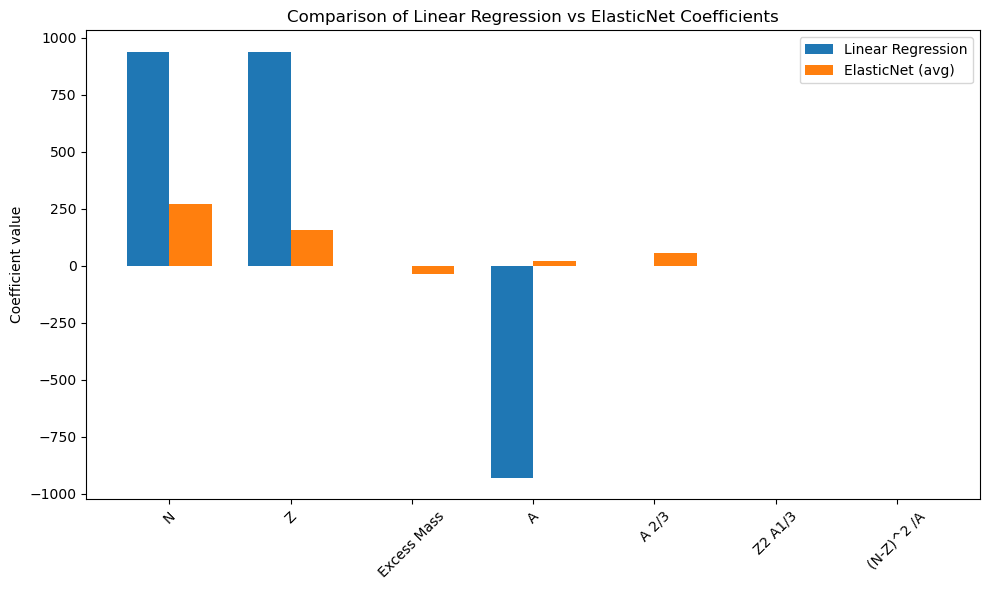

In [48]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold

# Fit LinearRegression across the same outer CV folds
kf = KFold(n_splits=5, shuffle=True, random_state=10)
lin_coefs_per_fold = []

for train_idx, test_idx in kf.split(X_train):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[test_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[test_idx]

    lin_model = LinearRegression()
    lin_model.fit(X_tr, y_tr)
    lin_coefs_per_fold.append(lin_model.coef_)

lin_coefs_per_fold = np.array(lin_coefs_per_fold)

# Average ElasticNet coefficients from previous block
elastic_avg_coefs = np.mean(coefs_per_fold, axis=0)
lin_avg_coefs = np.mean(lin_coefs_per_fold, axis=0)

feature_names = X_train.columns
x = np.arange(len(feature_names))
width = 0.35

plt.figure(figsize=(10,6))
plt.bar(x - width/2, lin_avg_coefs, width=width, label='Linear Regression')
plt.bar(x + width/2, elastic_avg_coefs, width=width, label='ElasticNet (avg)')

plt.xticks(x, feature_names, rotation=45)
plt.ylabel("Coefficient value")
plt.title("Comparison of Linear Regression vs ElasticNet Coefficients")
plt.legend()
plt.tight_layout()
plt.show()


Did regularization drive any of the coefficients to 0?

>No. Linear regression drove the Z2 A1/3 coefficient to 0. 

### Step 7: Make predictions and analyze the results

Apply the trained models to the blinded test data to make predictions of the binding energy for each atom, and compare the results to the true values.

Make the following plots to help you analyze the results:

- A scatter plot of binding energy vs. Z. Include the train and blinded test points, with different colors or markers to distinguish them.  
- A scatter plot of binding energy vs. A. Include the train and blinded test points, with different colors or markers to distinguish them.  
- A scatter plot of the liquid drop model residuals per nucleon (true BE - fit BE)/A vs. Z for the blinded test points, using the results from your best-performing model. 
- A scatter plot of the liquid drop model residuals per nucleon (true BE - fit BE)/A vs. A for the blinded test points, using the results from your best-performing model. 
- A color 2d scatter plot where Z is the y axis, N is the x axis, and color gives the value of the liquid drop model residuals per nucleon (true BE - fit BE)/A for all the instances. The inspiration here is the chart of the nuclides found at https://www.nndc.bnl.gov/nudat3/, where you can select "BE-LDM Fit/A" to plot these residuals for each nucleus, or this example on Wikipedia (https://en.wikipedia.org/wiki/Semi-empirical_mass_formula#/media/File:Semi-empirical_mass_formula_discrepancy.png). Their residuals won't agree with yours, since that fit includes an extra pairing interaction term that we didn't include. 


Do you notice a trend in the residuals as a function of either Z or A? Any other trends/features you noticed?





/opt/anaconda3/envs/PHYS448/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but ElasticNet was fitted without feature names
  warnings.warn(


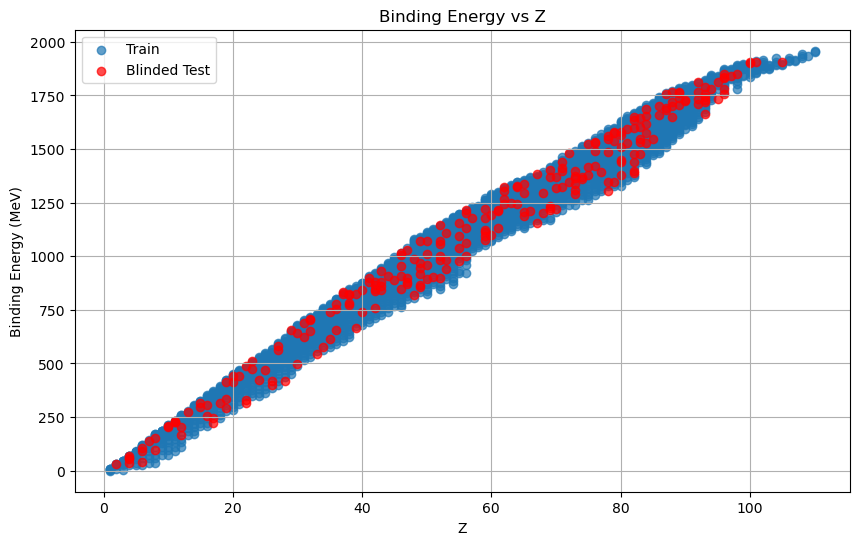

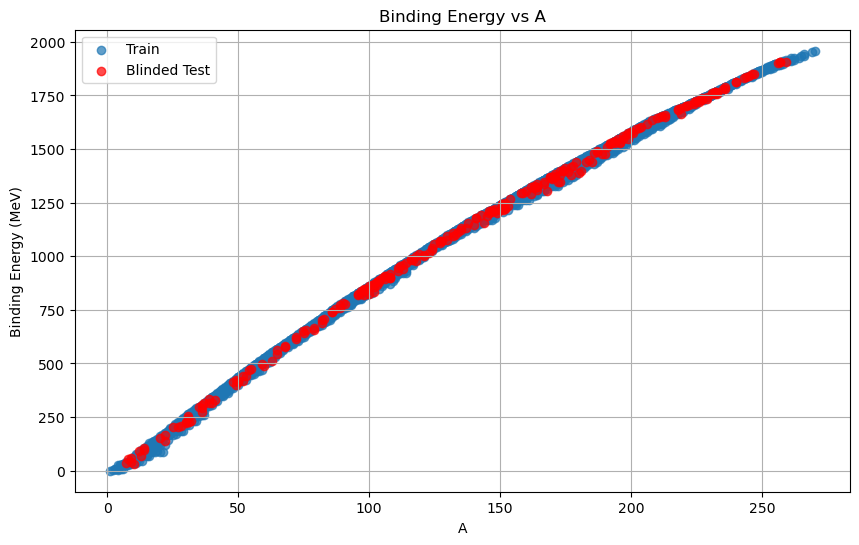

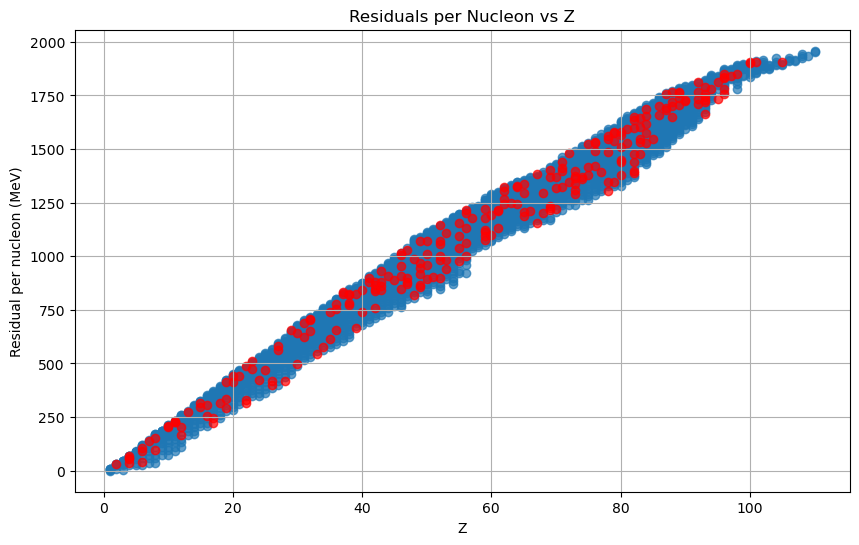

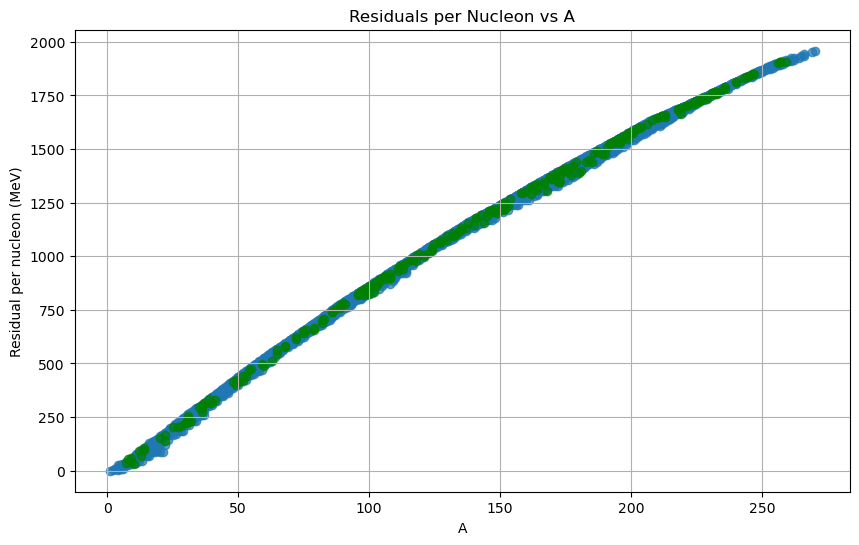

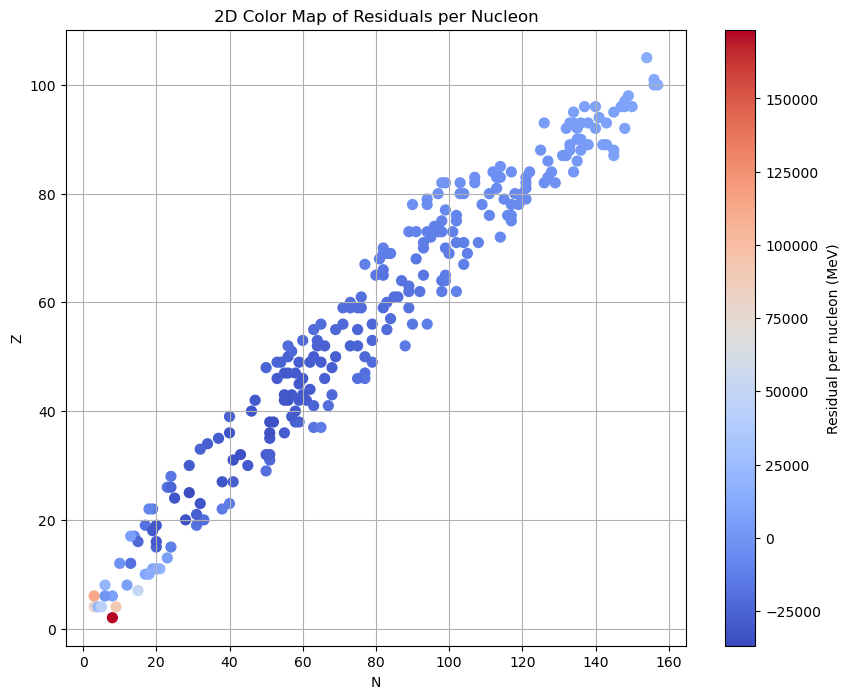

In [53]:
import matplotlib.pyplot as plt
import numpy as np

y_pred = model.predict(X_test)
residuals_per_nucleon = (y_test - y_pred) / X_test['A']

plt.figure(figsize=(10,6))
plt.scatter(X_train['Z'], y_train, label='Train', alpha=0.7)
plt.scatter(X_test['Z'], y_test, label='Blinded Test', alpha=0.7, color='red')
plt.xlabel("Z")
plt.ylabel("Binding Energy (MeV)")
plt.title("Binding Energy vs Z")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10,6))
plt.scatter(X_train['A'], y_train, label='Train', alpha=0.7)
plt.scatter(X_test['A'], y_test, label='Blinded Test', alpha=0.7, color='red')
plt.xlabel("A")
plt.ylabel("Binding Energy (MeV)")
plt.title("Binding Energy vs A")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10,6))
plt.scatter(X_train['Z'], y_train, label='Train', alpha=0.7)
plt.scatter(X_test['Z'], y_test, label='Blinded Test', alpha=0.7, color='red')
plt.xlabel("Z")
plt.ylabel("Residual per nucleon (MeV)")
plt.title("Residuals per Nucleon vs Z")
plt.grid(True)
plt.show()

plt.figure(figsize=(10,6))
plt.scatter(X_train['A'], y_train, label='Train', alpha=0.7)
plt.scatter(X_test['A'], y_test, label='Blinded Test', alpha=0.7, color='green')
plt.xlabel("A")
plt.ylabel("Residual per nucleon (MeV)")
plt.title("Residuals per Nucleon vs A")
plt.grid(True)
plt.show()

plt.figure(figsize=(10,8))
plt.scatter(X_test['N'], X_test['Z'], c=residuals_per_nucleon, cmap='coolwarm', s=50)
plt.colorbar(label='Residual per nucleon (MeV)')
plt.xlabel("N")
plt.ylabel("Z")
plt.title("2D Color Map of Residuals per Nucleon")
plt.grid(True)
plt.show()


>The spread on A is much tighter than the spread on Z. Both follow a linear trend. 

>The author acknowledges the use of ChatGPT for drafting code and diagnosing errors. 